# Part 1: Data Analysis

The goal of this notebook is to practice the techniques introduced in **Part 1: Data Analysis** of *Advances in Financial Machine Learning* by Marcos López de Prado. Through Python implementations and experiments with financial data, I aim to understand how these methods prepare data for financial machine learning.

The notebook is organized into four sections:

1. **Financial Data Structures** — Explore how financial observations are organized, sampled, and transformed into useful datasets.
2. **Labeling** — Practice assigning targets to financial observations, including the triple-barrier method and meta-labeling.
3. **Sample Weights** — Explore how overlapping observations, sample uniqueness, and time decay affect the weight assigned to each training example.
4. **Fractionally Differentiated Features** — Practice fractional differentiation to balance stationarity with the preservation of information from past observations.

Each section will combine explanations, code, and observations from the results to build a practical understanding of the techniques.


## Study Signal: Wilder's 14-Period RSI

We will use **Wilder's 14-period Relative Strength Index (RSI)** to define entry signals, first for **MSFT**, then for each stock in the small-, medium-, and large-cap baskets. A period is one price bar: 14 hourly bars with `interval="1H"` or 14 daily bars with `interval="1D"`.

### RSI calculation

For closing price $P_t$, define the price change, gain, and nonnegative loss:

$$
\Delta P_t=P_t-P_{t-1},\qquad
G_t=\max(\Delta P_t,0),\qquad
L_t=\max(-\Delta P_t,0).
$$

Initialize the averages with the first 14 price changes (requiring 15 closing prices):

$$
\overline{G}_{14}=\frac{1}{14}\sum_{i=1}^{14}G_i,
\qquad
\overline{L}_{14}=\frac{1}{14}\sum_{i=1}^{14}L_i.
$$

For subsequent bars, apply Wilder's recursive smoothing:

$$
\overline{G}_t=\frac{13\overline{G}_{t-1}+G_t}{14},
\qquad
\overline{L}_t=\frac{13\overline{L}_{t-1}+L_t}{14}.
$$

Relative strength and RSI are then:

$$
RS_t=\frac{\overline{G}_t}{\overline{L}_t},
\qquad
RSI_t=100-\frac{100}{1+RS_t}.
$$

If average loss is zero and average gain is positive, RSI is 100; if average gain is zero and average loss is positive, RSI is 0. For this study, we will assign RSI = 50 when both averages are zero. RSI remains unavailable until the initial 14 price changes exist.

### Entry rules

We interpret crossing oversold as entering below 30, and crossing overbought as entering above 70:

$$
s_t=
\begin{cases}
+1 & \text{if } RSI_{t-1}\geq30\text{ and }RSI_t<30\quad\text{(long entry)},\\
-1 & \text{if } RSI_{t-1}\leq70\text{ and }RSI_t>70\quad\text{(short entry)},\\
0 & \text{otherwise (no new entry)}.
\end{cases}
$$

The signal is an entry event rather than a continuously held position. Staying beyond a threshold does not generate another entry. Evaluate crossings only when both RSI values are available, and act after bar $t$ closes. Holding periods and exits will be specified in the labeling study.

**Reference:** [RSI calculation and Wilder smoothing — StockCharts ChartSchool](https://chartschool.stockcharts.com/table-of-contents/technical-indicators-and-overlays/technical-indicators/relative-strength-index-rsi).


Loaded 3,476 hourly bars
Available range: 2024-10-07 09:30:00-04:00 to 2026-10-06 13:30:00-04:00


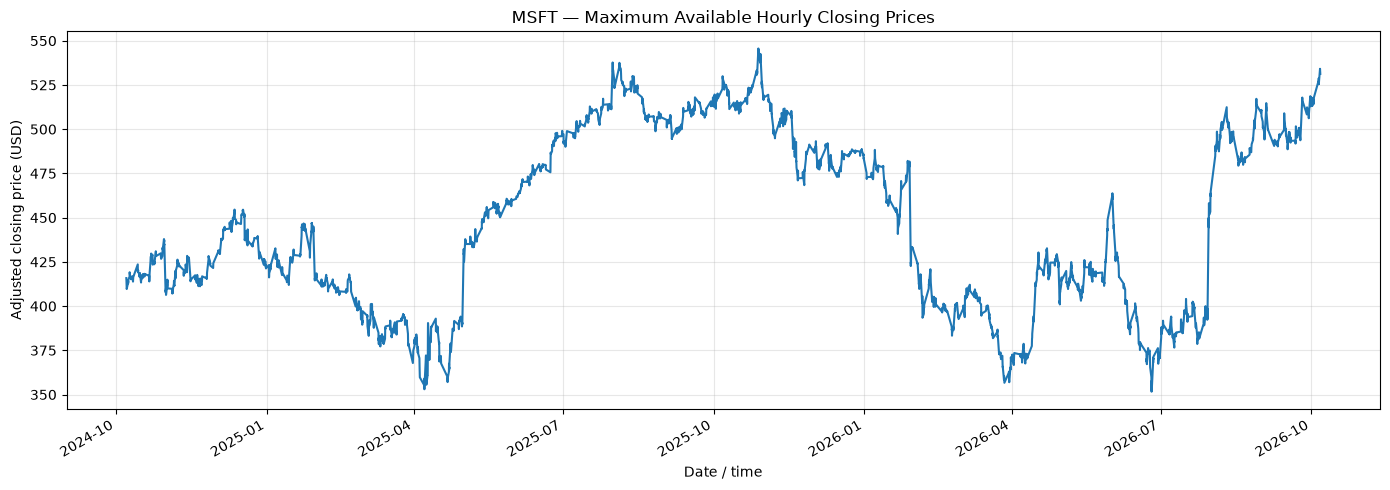

In [28]:
import matplotlib.pyplot as plt
import yfinance as yf
import pandas as pd

# Request the maximum hourly history Yahoo Finance makes available.
# Hourly history is limited to roughly the most recent 730 days.
msft_hourly = yf.Ticker("MSFT").history(
    period="max",
    interval="1h",
    auto_adjust=True,
)
if msft_hourly.empty:
    raise ValueError("Yahoo Finance returned no hourly MSFT data.")

msft_hourly = msft_hourly.sort_index()
msft_prices = msft_hourly[["Close"]].rename(columns={"Close": "MSFT"})
print(f"Loaded {len(msft_prices):,} hourly bars")
print(f"Available range: {msft_prices.index.min()} to {msft_prices.index.max()}")

ax = msft_prices.plot(
    figsize=(14, 5),
    legend=False,
    title="MSFT — Maximum Available Hourly Closing Prices",
)
ax.set_xlabel("Date / time")
ax.set_ylabel("Adjusted closing price (USD)")
ax.grid(True, alpha=0.3)
plt.tight_layout()
plt.show()


,MSFT
Datetime,
2024-10-07 10:30:00-04:00,-0.108223
2024-10-07 11:30:00-04:00,-0.227510
2024-10-07 12:30:00-04:00,-0.256983
2024-10-07 13:30:00-04:00,-0.234655
2024-10-07 14:30:00-04:00,-0.529260


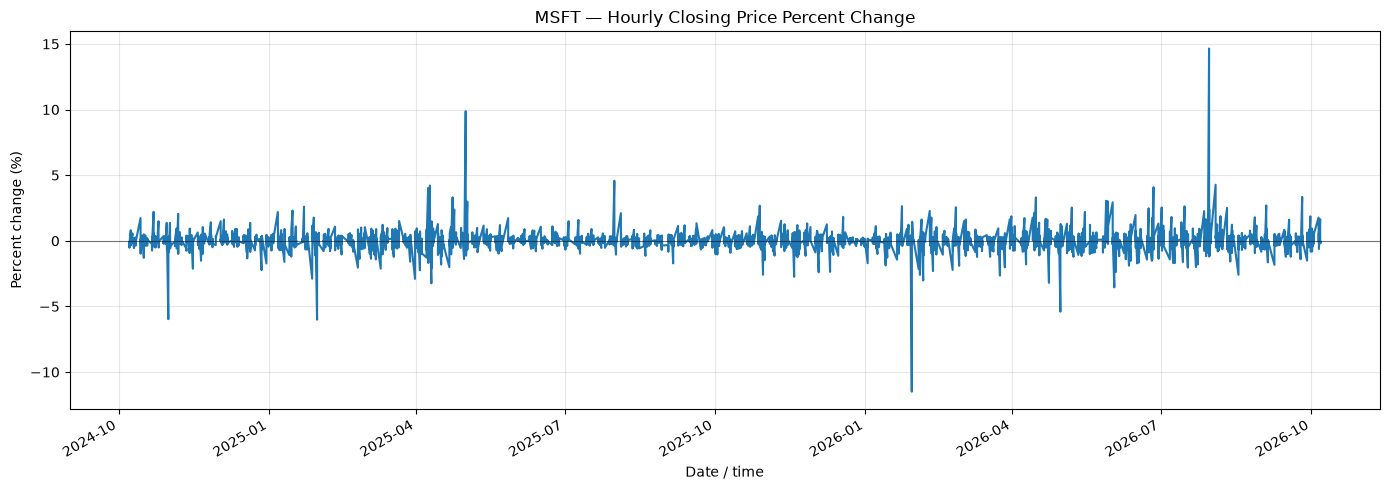

In [29]:
# Percent change between consecutive observed hourly closing prices.
# Drop the first bar, which has no previous price to compare against.
msft_pct_change = msft_prices.pct_change(fill_method=None).dropna() * 100
display(msft_pct_change.head())

ax = msft_pct_change.plot(
    figsize=(14, 5),
    legend=False,
    title="MSFT — Hourly Closing Price Percent Change",
)
ax.set_xlabel("Date / time")
ax.set_ylabel("Percent change (%)")
ax.axhline(0, color="black", linewidth=0.8, alpha=0.5)
ax.grid(True, alpha=0.3)
plt.tight_layout()
plt.show()


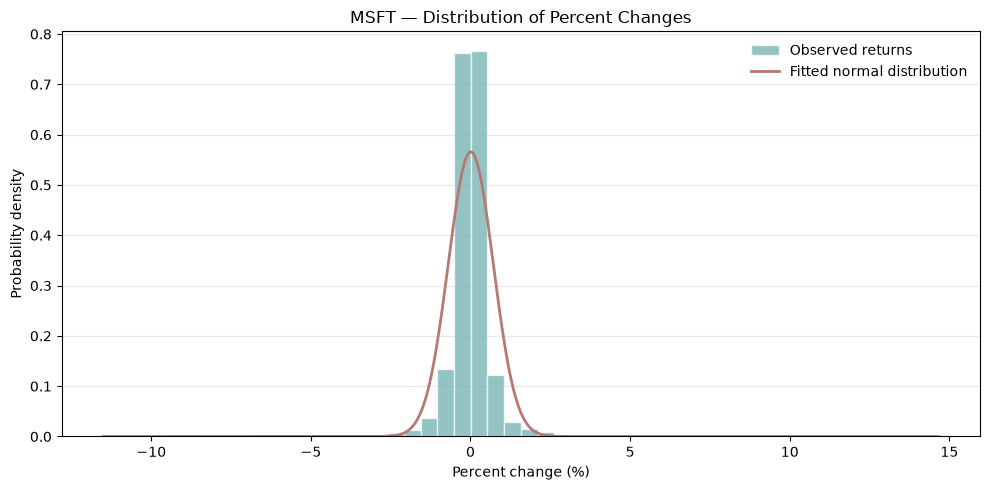

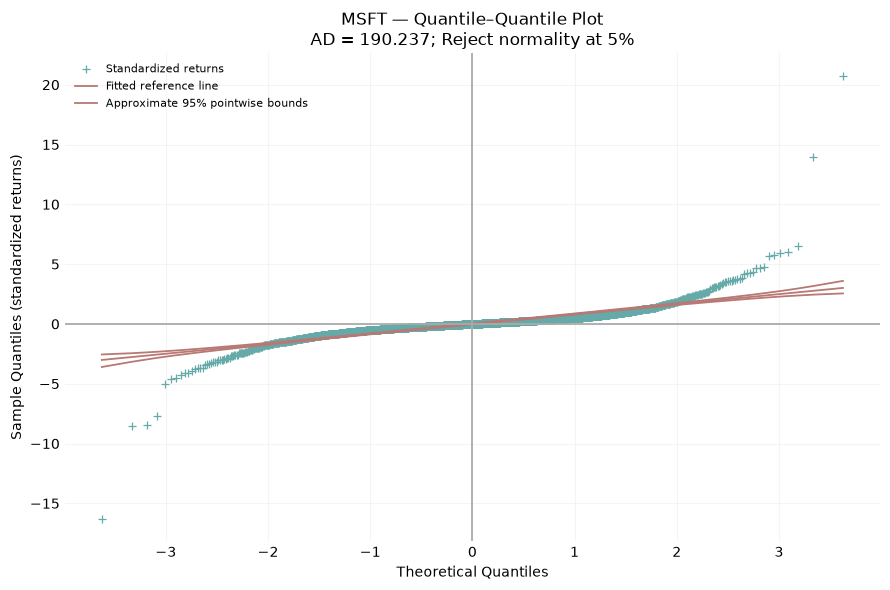

,n_obs,statistic,significance_level,critical_value,p_value,reject_normality,status
ticker,,,,,,,
MSFT,3475,190.236551,5.0,NaN,0.01,True,ok


In [30]:
from pathlib import Path
import sys

project_root = next(
    (folder for folder in (Path.cwd(), *Path.cwd().parents)
     if (folder / "HelperFunctions" / "sci_functions.py").is_file()),
    None,
)
if project_root is None:
    raise FileNotFoundError("Cannot locate HelperFunctions/sci_functions.py.")
if str(project_root) not in sys.path:
    sys.path.insert(0, str(project_root))

from HelperFunctions.sci_functions import return_normality

# Accepts multiple ticker columns; use input_type="prices" for price data.
msft_normality = return_normality(
    msft_pct_change,
    input_type="pct_change",
    plot_qq=True,
    plot_distribution=True,
    significance_level=5.0,
)
display(msft_normality)


## RSI Entry Signals

Calculate RSI from the same closing prices used for labeling. Buy signals mark crossings below 30; sell signals mark crossings above 70 when `allow_short=True`. Set `allow_short=False` for long-only entries. Warm-up bars generate no signals.


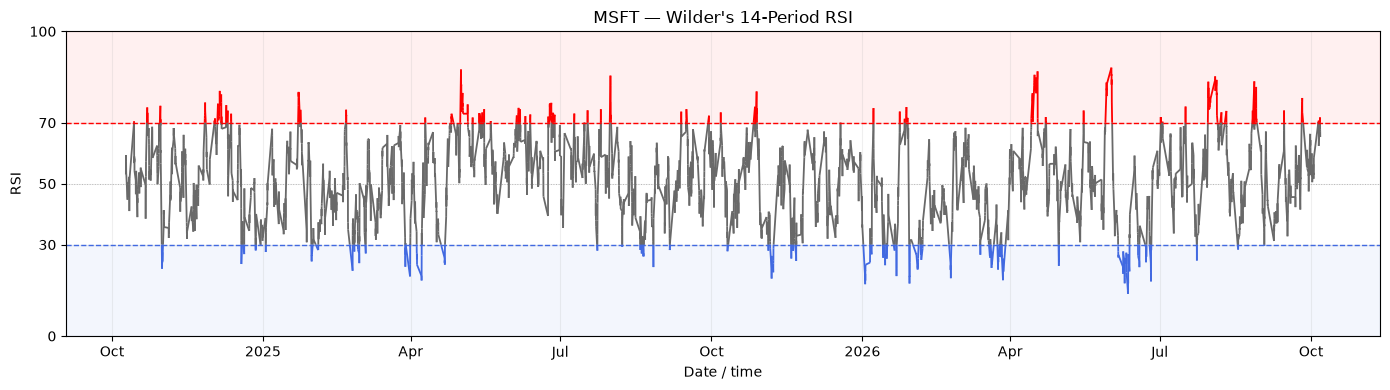

Total signals: 144
Buy signals (long entries): 65
Sell signals (short entries): 79


In [31]:
from HelperFunctions.signals import wilder_rsi

# Set False for long-only entries; rerun this and downstream cells after changing.
allow_short = True

msft_rsi = wilder_rsi(msft_prices, periods=14, plot=True)
previous_rsi = msft_rsi.shift(1)
valid_rsi = msft_rsi.notna() & previous_rsi.notna()
buy_signals = valid_rsi & (previous_rsi >= 30) & (msft_rsi < 30)
sell_signals = valid_rsi & (previous_rsi <= 70) & (msft_rsi > 70) & allow_short

buy_count = int(buy_signals.to_numpy().sum())
sell_count = int(sell_signals.to_numpy().sum())
print(f"Total signals: {buy_count + sell_count:,}")
print(f"Buy signals (long entries): {buy_count:,}")
print(f"Sell signals (short entries): {sell_count:,}")


## Triple-Barrier Meta-Labels

**Reference:** Marcos López de Prado (2018), *Advances in Financial Machine Learning*, Part 1, Chapter 3, **Labeling**: §3.3 **Computing Dynamic Thresholds**, §3.4 **The Triple-Barrier Method**, and §§3.6–3.7 **Meta-Labeling** and **How to Use Meta-Labeling**. Relevant implementation examples are Snippet 3.1 (volatility), Snippet 3.4 (vertical barriers), and Snippets 3.6–3.7 (events and binary meta-labels).

Our study adapts the framework to consecutive-bar volatility and close-only monitoring. Every RSI crossing is an independent event, including overlapping trades. The RSI rule supplies the side $s_i\in\{+1,-1\}$; the labeling algorithm determines the historical outcome. It does not train a model.

### Volatility target

For closing price $P_t$, consecutive-bar simple returns are:

$$
r_t=\frac{P_t}{P_{t-1}}-1,
\qquad
\alpha=\frac{2}{S+1},
$$

where $S$ is the configurable EWMA span in bars. For the valid returns available through $t$, normalized exponential weights and their weighted mean are:

$$
w_{t,k}=\frac{(1-\alpha)^{t-k}}{\sum_{j=1}^{t}(1-\alpha)^{t-j}},
\qquad
\mu_t=\sum_{k=1}^{t}w_{t,k}r_k.
$$

The bias-corrected weighted standard deviation used by `ewm(adjust=True).std(bias=False)` is:

$$
\sigma_t=
\sqrt{\frac{\sum_{k=1}^{t}w_{t,k}(r_k-\mu_t)^2}
{1-\sum_{k=1}^{t}w_{t,k}^2}}.
$$

The volatility frequency follows the data, with no annualization: hourly bars produce hourly-return volatility. For event $i$, freeze $\sigma_i=\sigma_{t_i}$ at its signal-close entry time $t_i$. Warm-up and minimum-target filters can exclude events with unavailable or insufficient volatility.

### Horizontal and vertical barriers

Enter at $P_{t_i}$ and monitor only subsequent closing prices. The side-adjusted return is:

$$
R_i(t)=s_i\left(\frac{P_t}{P_{t_i}}-1\right),\qquad t>t_i.
$$

With independent positive multipliers $m_{\mathrm{PT}}$ and $m_{\mathrm{SL}}$, the first horizontal touches are:

$$
\tau_i^{\mathrm{PT}}=\inf\{t>t_i:R_i(t)\geq m_{\mathrm{PT}}\sigma_i\},
$$

$$
\tau_i^{\mathrm{SL}}=\inf\{t>t_i:R_i(t)\leq -m_{\mathrm{SL}}\sigma_i\}.
$$

Equivalently, their price levels are:

$$
P_i^{\mathrm{PT}}=P_{t_i}(1+s_i m_{\mathrm{PT}}\sigma_i),
\qquad
P_i^{\mathrm{SL}}=P_{t_i}(1-s_i m_{\mathrm{SL}}\sigma_i).
$$

For a configurable holding limit of $D$ calendar days, use the first observed close at or after the elapsed-time deadline:

$$
\tau_i^{\mathrm{V}}=\inf\{t\in\mathcal{T}:t\geq t_i+D\text{ days}\},
\qquad
t_{1,i}=\min(\tau_i^{\mathrm{PT}},\tau_i^{\mathrm{SL}},\tau_i^{\mathrm{V}}),
$$

where $\mathcal{T}$ contains the observed bar timestamps. An untouched or unavailable barrier has no finite touch time. A horizontal touch on the vertical-exit close takes precedence when recording the exit reason. Exits use the observed closing price, which may overshoot the theoretical barrier.

### Binary meta-labels

For a completed event, realized return and label are:

$$
\mathrm{ret}_i=s_i\left(\frac{P_{t_{1,i}}}{P_{t_i}}-1\right),
\qquad
y_i=\mathbf{1}\{\mathrm{ret}_i>0\}.
$$

Profit-taking exits receive **1**; stop-loss exits receive **0**. Time exits receive **1** when profitable and **0** when losing or flat. Returns ignore trading costs. If the dataset ends before the vertical exit and no horizontal barrier was touched, the event remains **incomplete** and receives no label. Preserve all event IDs and entry/exit timestamps for the subsequent overlap analysis.


In [32]:
import pandas as pd
from HelperFunctions.labeling import estimate_volatility, create_events, get_labels

# Adjustable study parameters. Span and warm-up are measured in data bars.
volatility_span = 100
volatility_min_periods = 2
profit_taking_multiplier = 1.0
stop_loss_multiplier = 1.0
max_holding_days = 7
min_target_return = 0.0

# All crossings are independent entries, including overlapping trades.
trade_sides = buy_signals.astype(int) - sell_signals.astype(int)
msft_volatility = estimate_volatility(
    msft_prices, span=volatility_span, min_periods=volatility_min_periods
)
msft_events = create_events(
    msft_prices,
    trade_sides,
    volatility=msft_volatility,
    pt_mult=profit_taking_multiplier,
    sl_mult=stop_loss_multiplier,
    holding_days=max_holding_days,
    min_ret=min_target_return,
)
msft_labels = get_labels(msft_events)

print(f"Total signal events: {len(msft_events):,}")
print("Event status counts:")
print(msft_events["status"].value_counts().to_string())
print("\nCompleted exit counts:")
print(msft_labels["exit_type"].value_counts().to_string())
print(f"\nProfitable labels (1): {int(msft_labels['bin'].eq(1).sum()):,}")
print(f"Unprofitable/flat labels (0): {int(msft_labels['bin'].eq(0).sum()):,}")
display(msft_events.head())
display(msft_labels.head())


Total signal events: 144
Event status counts:
status
complete      143
incomplete      1

Completed exit counts:
exit_type
stop_loss        72
profit_taking    69
time              2

Profitable labels (1): 71
Unprofitable/flat labels (0): 72


,ticker,signal_time,entry_time,entry_price,side,trgt,pt_mult,sl_mult,pt_return,sl_return,...,sl_price,deadline,vertical_time,status,exclusion_reason,pt_time,sl_time,t1,exit_type,exit_price
event_id,,,,,,,,,,,,,,,,,,,,,
0,MSFT,2024-10-14 09:30:00-04:00,2024-10-14 09:30:00-04:00,423.595001,-1,0.004395,1.0,1.0,0.004395,-0.004395,...,425.456863,2024-10-21 09:30:00-04:00,2024-10-21 09:30:00-04:00,complete,None,2024-10-14 10:30:00-04:00,NaT,2024-10-14 10:30:00-04:00,profit_taking,419.429993
1,MSFT,2024-10-22 09:30:00-04:00,2024-10-22 09:30:00-04:00,428.070007,-1,0.005051,1.0,1.0,0.005051,-0.005051,...,430.232308,2024-10-29 09:30:00-04:00,2024-10-29 09:30:00-04:00,complete,None,2024-10-23 12:30:00-04:00,NaT,2024-10-23 12:30:00-04:00,profit_taking,425.139404
2,MSFT,2024-10-22 12:30:00-04:00,2024-10-22 12:30:00-04:00,427.350006,-1,0.004947,1.0,1.0,0.004947,-0.004947,...,429.464109,2024-10-29 12:30:00-04:00,2024-10-29 12:30:00-04:00,complete,None,NaT,2024-10-22 13:30:00-04:00,2024-10-22 13:30:00-04:00,stop_loss,429.695007
3,MSFT,2024-10-30 09:30:00-04:00,2024-10-30 09:30:00-04:00,437.869995,-1,0.004478,1.0,1.0,0.004478,-0.004478,...,439.830866,2024-11-06 08:30:00-05:00,2024-11-06 09:30:00-05:00,complete,None,2024-10-30 13:30:00-04:00,NaT,2024-10-30 13:30:00-04:00,profit_taking,434.529999
4,MSFT,2024-10-30 12:30:00-04:00,2024-10-30 12:30:00-04:00,437.424988,-1,0.004373,1.0,1.0,0.004373,-0.004373,...,439.337967,2024-11-06 11:30:00-05:00,2024-11-06 11:30:00-05:00,complete,None,2024-10-30 13:30:00-04:00,NaT,2024-10-30 13:30:00-04:00,profit_taking,434.529999


,ticker,entry_time,t1,side,exit_type,raw_return,ret,bin
event_id,,,,,,,,
0,MSFT,2024-10-14 09:30:00-04:00,2024-10-14 10:30:00-04:00,-1,profit_taking,-0.009833,0.009833,1
1,MSFT,2024-10-22 09:30:00-04:00,2024-10-23 12:30:00-04:00,-1,profit_taking,-0.006846,0.006846,1
2,MSFT,2024-10-22 12:30:00-04:00,2024-10-22 13:30:00-04:00,-1,stop_loss,0.005487,-0.005487,0
3,MSFT,2024-10-30 09:30:00-04:00,2024-10-30 13:30:00-04:00,-1,profit_taking,-0.007628,0.007628,1
4,MSFT,2024-10-30 12:30:00-04:00,2024-10-30 13:30:00-04:00,-1,profit_taking,-0.006618,0.006618,1


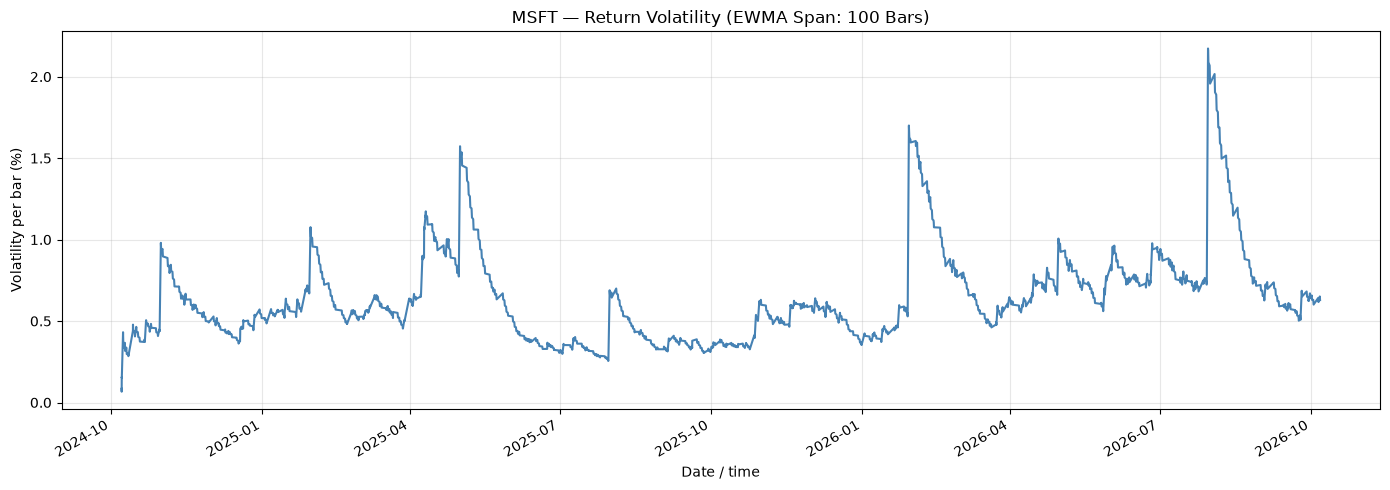

In [33]:
# Volatility is the standard deviation of returns at the input bar frequency.
ax = (msft_volatility * 100).plot(
    figsize=(14, 5),
    legend=False,
    color="steelblue",
    title=f"MSFT — Return Volatility (EWMA Span: {volatility_span} Bars)",
)
ax.set_xlabel("Date / time")
ax.set_ylabel("Volatility per bar (%)")
ax.grid(True, alpha=0.3)
plt.tight_layout()
plt.show()


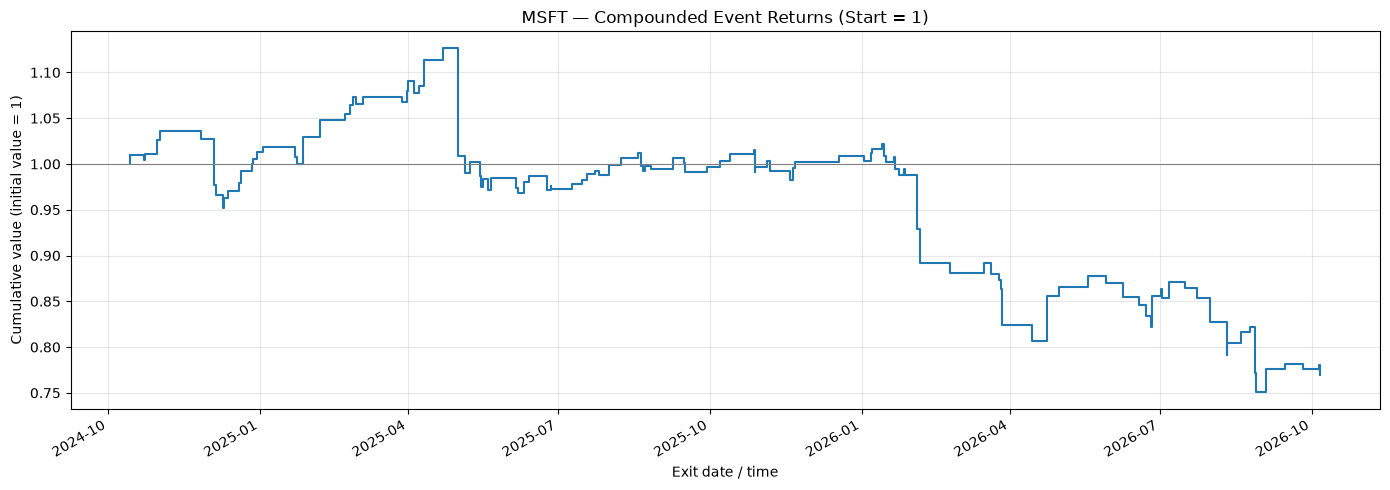

In [34]:
from HelperFunctions.signals import plot_cumulative_returns

# Start at 1 and multiply by (1 + trade return) in exit-time order.
# Overlapping events are retained; this is an event-return summary.
msft_cumulative_returns = plot_cumulative_returns(msft_events, max_workers=32)


## Event Feature Data

Each row in `msft_event_features` describes one event at its signal bar's close and retains the `event_id` index. `msft_event_metadata` holds ticker and signal timestamp separately. All price-based inputs use adjusted prices. Returns below are percentage points unless explicitly described as fractions.

**Timing:** `t` denotes an hourly bar, `P_t` its closing price, and `d` the last trading session strictly before the signal's New York date. Daily inputs never use the current session's eventual close. A trading session is one observed daily price row; weekends and exchange holidays are excluded. Hourly lookbacks count observed bars and can cross overnight gaps. Yahoo's hourly timestamps label the **start** of a bar; its final regular-session bar can be shorter than 60 minutes. The time feature below deliberately describes that start, while the price and volume inputs become available at the bar's close.

| Feature column | Exact calculation and units |
|---|---|
| `volatility_ewma` | Existing `msft_volatility` at the signal bar: standard deviation of 1-bar fractional returns using `ewm(span=100, min_periods=2, adjust=True).std(bias=False)` under the current labeling settings. No annualization. If labeling parameters change, this feature follows them. |
| `volatility_ratio20_100` | EWMA standard deviation with span 20 bars and minimum 20 returns divided by EWMA standard deviation with span 100 bars and minimum 100 returns; both use `adjust=True`, `bias=False`. Unitless. |
| `volume_shares` | Shares traded during the signal bar. |
| `relative_volume20_sessions` | Signal-bar volume divided by the mean volume of the previous 20 observed sessions' bars with the same New York start hour and minute. Current bar excluded; requires 20 prior observations of that slot. Unitless. |
| `above_daily_sma50` | 1 if `P_t` exceeds the mean of 50 completed daily closes ending at `d`; 0 otherwise, including equality. Missing until 50 daily closes exist. |
| `distance_daily_sma50_pct` | `100 * (P_t / SMA50_d - 1)`, using those same 50 completed daily closes. |
| `daily_sma50_slope5_pct` | `100 * (SMA50_d / SMA50_(d-5) - 1)`. Five trading-session change in the daily 50-session SMA; requires 55 daily closes. |
| `return_1_bars_pct` | `100 * (P_t / P_(t-1) - 1)`: return across 1 observed hourly bar. |
| `return_3_bars_pct` | `100 * (P_t / P_(t-3) - 1)`: cumulative return across 3 observed hourly bars. |
| `return_6_bars_pct` | `100 * (P_t / P_(t-6) - 1)`: cumulative return across 6 observed hourly bars. |
| `return_5_daily_sessions_pct` | `100 * (Close_d / Close_(d-5) - 1)`: cumulative stock return across 5 completed trading sessions, excluding the signal's session. |
| `rsi14` | Wilder's 14-bar RSI at the signal bar; range 0–100. |
| `rsi14_change1_bar` | `RSI_t - RSI_(t-1)`, in RSI points. |
| `overnight_gap_pct` | `100 * (current session's first observed hourly Open / previous completed daily Close - 1)`. Missing first-session opening bars can make this a first-observed-bar gap rather than the exchange opening gap. |
| `bar_start_minutes_since0930` | Hourly bar's New York start time minus 09:30, in minutes; e.g. 09:30 = 0, 10:30 = 60, 15:30 = 360. |
| `weekday` | New York trading weekday: Monday = 0, Tuesday = 1, Wednesday = 2, Thursday = 3, Friday = 4. |
| `spy_return_3_daily_sessions_pct` | `100 * (SPY_Close_d / SPY_Close_(d-3) - 1)`: cumulative SPY return across exactly 3 completed trading sessions. This is a compounded endpoint return, not a sum of daily returns. |

Lookback shortages remain missing; no backward filling or automatic event deletion occurs. Bar structure, trade direction, benchmark volatility, and stock-minus-benchmark returns are excluded. Fundamentals are deferred until historical publication-time data are available. `side`, realized return, exit time, and meta-label are not feature columns.


In [35]:
from HelperFunctions.features import event_features

# Extra daily history warms up the 50-session SMA and its 5-session slope.
feature_start = msft_prices.index.min().date() - pd.Timedelta(days=180)
feature_end = msft_prices.index.max().date() + pd.Timedelta(days=1)
msft_daily_features = yf.Ticker("MSFT").history(
    start=feature_start, end=feature_end, interval="1d", auto_adjust=True,
)
spy_daily_features = yf.Ticker("SPY").history(
    start=feature_start, end=feature_end, interval="1d", auto_adjust=True,
)
if msft_daily_features.empty or spy_daily_features.empty:
    raise ValueError("Daily MSFT and SPY data are required for event features.")

msft_event_features, msft_event_metadata = event_features(
    hourly={"MSFT": msft_hourly},
    daily={"MSFT": msft_daily_features},
    spy_daily=spy_daily_features,
    events=msft_events,
    volatility=msft_volatility,
    rsi=msft_rsi,
)
print(f"Feature table: {msft_event_features.shape[0]:,} events, "
      f"{msft_event_features.shape[1]} features")
display(msft_event_features.head())
display(msft_event_features.isna().sum().rename("missing_events").to_frame())


Feature table: 144 events, 18 features


,volatility_ewma,volatility_ratio20_100,volume_shares,relative_volume20_sessions,above_daily_sma50,distance_daily_sma50_pct,daily_sma50_slope5_pct,return_1_bars_pct,return_3_bars_pct,return_6_bars_pct,return_5_daily_sessions_pct,rsi14,rsi14_change1_bar,rsi14_threshold_distance,overnight_gap_pct,bar_start_minutes_since0930,weekday,spy_return_3_daily_sessions_pct
event_id,,,,,,,,,,,,,,,,,,
0,0.004395,NaN,3743589.0,NaN,1.0,3.033240,-0.156420,1.730346,2.017003,1.994896,0.062490,70.447830,18.687200,0.447830,1.923748,0.0,0.0,1.118337
1,0.005051,NaN,7236351.0,NaN,1.0,3.617517,0.431841,2.206151,2.732282,3.411039,-0.085890,75.018120,17.826794,5.018120,1.633068,0.0,1.0,0.228381
2,0.004947,NaN,1064219.0,NaN,1.0,3.443235,0.431841,0.333391,-0.168197,2.559489,-0.085890,70.061030,2.165832,0.061030,1.633068,180.0,1.0,0.228381
3,0.004478,1.077396,6001246.0,NaN,1.0,5.652080,0.217173,1.365834,1.265033,1.941656,1.038577,75.559353,11.641937,5.559353,2.869566,0.0,2.0,0.436774
4,0.004373,1.005388,1845612.0,NaN,1.0,5.544705,0.217173,0.250978,-0.101630,1.162117,1.038577,71.120558,1.976675,1.120558,2.869566,180.0,2.0,0.436774


,missing_events
volatility_ewma,0
volatility_ratio20_100,3
volume_shares,0
relative_volume20_sessions,6
above_daily_sma50,0
distance_daily_sma50_pct,0
daily_sma50_slope5_pct,0
return_1_bars_pct,0
return_3_bars_pct,0
return_6_bars_pct,0


In [ ]:
# Drop an event if ANY of its feature values is missing.
complete_feature_mask = msft_event_features.notna().all(axis=1)
msft_event_features_clean = msft_event_features.loc[complete_feature_mask].copy()
retained_event_ids = msft_event_features_clean.index

# Preserve event IDs and apply the same selection to related tables.
msft_events_clean = msft_events.loc[retained_event_ids].copy()
msft_event_metadata_clean = msft_event_metadata.loc[retained_event_ids].copy()
msft_labels_clean = msft_labels.loc[
    msft_labels.index.isin(retained_event_ids)
].copy()

print(f"Dropped {int((~complete_feature_mask).sum()):,} events with missing features")
print(f"Retained {len(msft_event_features_clean):,} events with all features available")
print(f"Retained {len(msft_labels_clean):,} completed-event labels")
display(msft_event_features_clean.head())
